# Notebook 06：中性化与稳健性

本 Notebook 检验 Notebook 04、05 中观察到的单因子预测能力，是否只是市值或行业暴露的结果。核心比较对象为因子的 `IC` 和 根据因子分组的 `Q5-Q1` 在 `Raw Factor`、`Size Neutral`、`Industry Neutral` 和 `Industry + Size Neutral` 四种规格下的计算结果，由 Mean Rank IC / ICIR / 累计 IC 和 年化收益 / Sharpe / 复利累计收益 描述；同时检查中性化后因子与市值的线性相关以及行业内因子均值是否接近零，以验证目标暴露确实被消除。

## 理论基础：中性化在回答什么问题

原始因子可能同时包含目标选股信息和系统性暴露。例如，一个高分因子若长期偏向小市值股票，其收益可能来自小盘风格，而非因子本身。中性化使用横截面回归，将可由控制变量线性解释的部分从因子中剔除，再检验剩余部分是否仍能预测下一期收益。

这里的 `Raw Factor` 指已经完成去极值、方向统一和横截面标准化、但没有做市值或行业中性化的基准因子，不是完全未经处理的财务原始值。

### 1. 市值、行业与联合中性化

每个信号形成日 $t$ 单独做一次横截面 OLS。市值中性化使用：

$$f_{i,t}=\alpha_t+\beta_t\ln(MarketCap_{i,t})+\epsilon_{i,t}.$$

行业中性化使用含截距和 $K-1$ 个行业虚拟变量的回归：

$$f_{i,t}=\alpha_t+\sum_{k=1}^{K-1}\gamma_{k,t}Industry_{i,k,t}+\epsilon_{i,t}.$$

联合中性化同时控制两类暴露：

$$f_{i,t}=\alpha_t+\beta_t\ln(MarketCap_{i,t})+\sum_{k=1}^{K-1}\gamma_{k,t}Industry_{i,k,t}+\epsilon_{i,t}.$$

三种中性化规格都使用残差 $\epsilon_{i,t}$ 作为新信号，即中性化的因子值。因此中性化可以理解为扣除了市值、行业的影响和基准($\alpha_t$)后的"有效"因子。含截距 OLS 的样本残差与设计矩阵列正交，因此市值中性化残差与 `log market cap` 的当月 Pearson 相关应接近零；行业中性化残差在每个当月行业内的均值应接近零。

### 2. 处理顺序、可比样本与解释边界

理论处理顺序为：`合格股票池 → 去极值 → 方向统一 → 中性化 → 残差 Z-score`。实现中先复用 `build_zscore_factor_panel()`，再对其输出回归并重新标准化。由于含截距 OLS 对因变量的正仿射变换具有等变性，这与先对去极值且方向统一的因子回归、最后标准化残差得到相同的最终信号。

为了让四个版本的差异只来自中性化，本 Notebook 对每个因子使用四个版本均有值的共同股票—月份样本，并沿用 Notebook 04、05 的 Rank IC、ICIR、五分位数组合和 Q5−Q1 指标。

需要注意：因子残差的样本内线性正交不等于最终投资组合严格风险中性。分组、等权和持仓约束都可能重新引入暴露；本节也尚未计入交易成本和做空约束。

### 3. Rank IC 序列：Mean Rank IC、ICIR 与累计 IC

在每个信号形成日 $t$，使用当月股票横截面计算因子值与下一期收益的 Spearman 秩相关：

$$IC_t=\operatorname{Spearman}(Factor_{i,t},Return_{i,t+1}).$$

Spearman 衡量的是**排名之间的相关性**。它先把因子值和未来收益分别转换成排名，再计算相关性。$IC_t>0$ 表示当月因子值较高的股票下一期通常具有较高收益；$IC_t<0$ 表示排序方向相反。一个因子在 $T$ 个持有期中会形成月度序列 $IC_1,\ldots,IC_T$，本节用以下指标描述它：

- **Mean Rank IC**：$\overline{IC}=\sum_{t=1}^{T}IC_t/T$，衡量平均横截面排序方向和强度。
- **ICIR**：${\rm ICIR}=\overline{IC}/{\rm Std}(IC)$，其中 ${\rm Std}(IC)$ 是月度 IC 的样本标准差。它衡量平均 IC 相对于月度波动是否稳定。ICIR 高，说明预测能力相对稳定。ICIR 低，说明平均效果可能主要由少数月份贡献。实践中有时会对 ICIR 乘 $\sqrt{12}$ 年化，比较结果时应确认双方是否都进行了年化。
- **IC 胜率**：${\rm Positive\ IC\ Ratio}={\rm Count}\{t:\, IC_t>0\}/T$，即 IC 为正的月份占比。
- **累计 IC**：${\rm Cumulative}\ IC_T=\sum_{t=1}^{T}IC_t$，用于观察预测能力随时间的积累、停滞和反转。它是相关系数的累计和，不是投资组合净值，也不能解释为可交易收益。

因此，Mean Rank IC 回答“平均方向是否正确”，ICIR 回答“这种方向是否稳定”，IC 胜率回答“方向正确的频率”，累计 IC 曲线回答“预测能力主要出现在哪些时期”。

### 4. Q5−Q1 序列：年化收益、Sharpe 与复利累计收益

每个信号形成日按因子值从低到高等频分成 Q1–Q5，组内等权。Q5−Q1 的月度收益为：

$$R_{LS,t}=R_{Q5,t}-R_{Q1,t}.$$

$R_{LS,t}>0$ 表示高因子组在该持有期跑赢低因子组；它衡量相对收益，即使 Q5 和 Q1 同时上涨或同时下跌也可以为正。对月度序列 $R_{LS,1},\ldots,R_{LS,T}$，本节计算：

- **年化收益**：$Annualized\ Return=[\prod_{t=1}^{T}(1+R_{LS,t})]^{12/T}-1$，是月度收益复利后的年化增长率，不是月收益均值简单乘以 12。
- **Sharpe**：在月度无风险利率取零时，$Sharpe=\overline{R}_{LS}/s(R_{LS})\times\sqrt{12}$，衡量每单位月度收益波动对应的平均收益。
- **复利累计收益**：$Cumulative\ Return_T=\prod_{t=1}^{T}(1+R_{LS,t})-1$，表示将月度 Q5−Q1 收益连续复利后的合成收益路径。负值表示截至该时点，高因子组累计上仍跑输低因子组。

累计 IC 使用加法，复利累计收益使用乘法；前者描述预测相关性的时间演化，后者描述理论多空收益的路径，二者不能相互替代。这里的 Q5−Q1 尚未计入融资融券、交易成本和成交约束，因此是研究型合成收益，不是可直接实现的账户净值。

## 1. 环境与研究参数

In [1]:
from pathlib import Path
import gc
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.factors import (
    build_neutralized_factor_panel,
    build_zscore_factor_panel,
    calculate_average_factor_correlation,
    calculate_factor_rank_autocorrelation,
    calculate_monthly_rank_ic,
    summarize_rank_ic,
)
from src.portfolio import (
    annualized_return,
    build_factor_return_panel,
    calculate_cumulative_returns,
    calculate_quintile_returns,
    calculate_return_metrics,
)

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_FACTOR_PATH = PROCESSED_DIR / 'factor_panel_raw.parquet'
MIN_OBSERVATIONS = 30
N_QUANTILES = 5
PERIODS_PER_YEAR = 12

FACTOR_LABELS = {
    'ep': 'EP',
    'bp': 'BP',
    'roe': 'ROE',
    'gross_profitability': 'GP',
    'momentum_12_1': 'MOM',
    'low_volatility_60d': 'LOWVOL',
}
FACTOR_COLUMNS = tuple(FACTOR_LABELS)
VERSIONS = (
    'Raw Factor',
    'Size Neutral',
    'Industry Neutral',
    'Industry + Size Neutral',
)
VERSION_COLORS = dict(zip(VERSIONS, sns.color_palette('colorblind', len(VERSIONS))))
ANALYSIS_COLUMNS = (
    'date', 'stock_code', 'future_return_1m', 'is_in_label_sample',
    'is_eligible', 'industry', 'size', *FACTOR_COLUMNS,
)
NEUTRAL_PANEL_PATHS = {
    'Size Neutral': PROCESSED_DIR / 'factor_panel_size_neutral.parquet',
    'Industry Neutral': PROCESSED_DIR / 'factor_panel_industry_neutral.parquet',
    'Industry + Size Neutral': PROCESSED_DIR / 'factor_panel_industry_size_neutral.parquet',
}

sns.set_theme(style='whitegrid', context='notebook')
print(f'项目目录：{PROJECT_ROOT}')
print(f'比较版本：{VERSIONS}')

项目目录：/Users/mac/Desktop/a-share-multifactor
比较版本：('Raw Factor', 'Size Neutral', 'Industry Neutral', 'Industry + Size Neutral')


## 2. 构造四种因子版本

三种中性化面板保留与原始面板相同的月度骨架和上下文字段，非合格股票的因子值保持缺失。`size` 是原始因子面板中的 $\ln(MarketCap)$，仅作为控制变量，不作为本节被中性化的 Alpha 因子。

In [2]:
raw_factor_panel = pd.read_parquet(RAW_FACTOR_PATH)
assert not raw_factor_panel.duplicated(['date', 'stock_code']).any()
assert set(ANALYSIS_COLUMNS).issubset(raw_factor_panel.columns)

baseline_full = build_zscore_factor_panel(
    raw_factor_panel, factor_columns=FACTOR_COLUMNS
)
panels = {'Raw Factor': baseline_full.loc[:, ANALYSIS_COLUMNS].copy()}
del baseline_full

neutralization_specs = {
    'Size Neutral': dict(neutralize_size=True, neutralize_industry=False),
    'Industry Neutral': dict(neutralize_size=False, neutralize_industry=True),
    'Industry + Size Neutral': dict(neutralize_size=True, neutralize_industry=True),
}
for version, specification in neutralization_specs.items():
    neutralized_full = build_neutralized_factor_panel(
        raw_factor_panel,
        factor_columns=FACTOR_COLUMNS,
        min_observations=MIN_OBSERVATIONS,
        **specification,
    )
    neutralized_full.to_parquet(NEUTRAL_PANEL_PATHS[version], index=False)
    panels[version] = neutralized_full.loc[:, ANALYSIS_COLUMNS].copy()
    del neutralized_full
    gc.collect()

reference_keys = panels['Raw Factor'][['date', 'stock_code']]
for version, panel in panels.items():
    assert panel[['date', 'stock_code']].equals(reference_keys)
    panel['date'] = pd.to_datetime(panel['date'])

print(
    f"完整骨架：{len(reference_keys):,} 行，"
    f"{panels['Raw Factor']['date'].nunique()} 个调仓日"
)
for version, path in NEUTRAL_PANEL_PATHS.items():
    print(f'{version}: {path.name} ({path.stat().st_size / 1024**2:.1f} MB)')

del raw_factor_panel
gc.collect()

完整骨架：426,474 行，96 个调仓日
Size Neutral: factor_panel_size_neutral.parquet (36.9 MB)
Industry Neutral: factor_panel_industry_neutral.parquet (36.8 MB)
Industry + Size Neutral: factor_panel_industry_size_neutral.parquet (36.8 MB)


0

## 3. 中性化有效性检查

市值暴露用逐月因子与 `size` 的 Pearson 相关系数绝对值衡量，再对月份取平均。行业暴露用逐月、逐行业因子均值的绝对值衡量；因子都已经标准化，因此该指标可跨版本比较。这里检验的是 OLS 的线性样本正交条件，不要求 Spearman 相关为零。

In [3]:
size_exposure = pd.DataFrame(index=FACTOR_COLUMNS, columns=VERSIONS, dtype=float)
industry_exposure = pd.DataFrame(index=FACTOR_COLUMNS, columns=VERSIONS, dtype=float)

for version, panel in panels.items():
    signal_sample = panel.loc[panel['is_eligible'].fillna(False)]
    for factor in FACTOR_COLUMNS:
        monthly_correlations = []
        for _, cross_section in signal_sample.groupby('date', sort=True, observed=True):
            paired = cross_section[[factor, 'size']].dropna()
            if len(paired) >= MIN_OBSERVATIONS:
                monthly_correlations.append(paired[factor].corr(paired['size']))
        size_exposure.loc[factor, version] = pd.Series(monthly_correlations).abs().mean()

        industry_means = (
            signal_sample[['date', 'industry', factor]]
            .dropna()
            .groupby(['date', 'industry'], observed=True)[factor]
            .mean()
        )
        industry_exposure.loc[factor, version] = industry_means.abs().mean()

assert size_exposure[['Size Neutral', 'Industry + Size Neutral']].max().max() < 1e-10
assert industry_exposure[['Industry Neutral', 'Industry + Size Neutral']].max().max() < 1e-10

exposure_diagnostics = pd.concat(
    {'Mean Absolute Size Correlation': size_exposure,
     'Mean Absolute Industry Mean': industry_exposure},
    names=['Metric', 'Factor'],
)
exposure_diagnostics.to_csv(PROCESSED_DIR / 'neutralization_exposure_diagnostics.csv')
display(size_exposure.rename(index=FACTOR_LABELS).style.format('{:.4f}'))
display(industry_exposure.rename(index=FACTOR_LABELS).style.format('{:.4f}'))

,Raw Factor,Size Neutral,Industry Neutral,Industry + Size Neutral
EP,0.2917,0.0000,0.2350,0.0000
BP,0.0828,0.0000,0.0434,0.0000
ROE,0.3087,0.0000,0.2884,0.0000
GP,0.1704,0.0000,0.1884,0.0000
MOM,0.2363,0.0000,0.2250,0.0000
LOWVOL,0.1594,0.0000,0.1358,0.0000


,Raw Factor,Size Neutral,Industry Neutral,Industry + Size Neutral
EP,0.3180,0.3058,0.0000,0.0000
BP,0.5184,0.5107,0.0000,0.0000
ROE,0.2234,0.2200,0.0000,0.0000
GP,0.4266,0.4436,0.0000,0.0000
MOM,0.2675,0.2775,0.0000,0.0000
LOWVOL,0.3643,0.3542,0.0000,0.0000


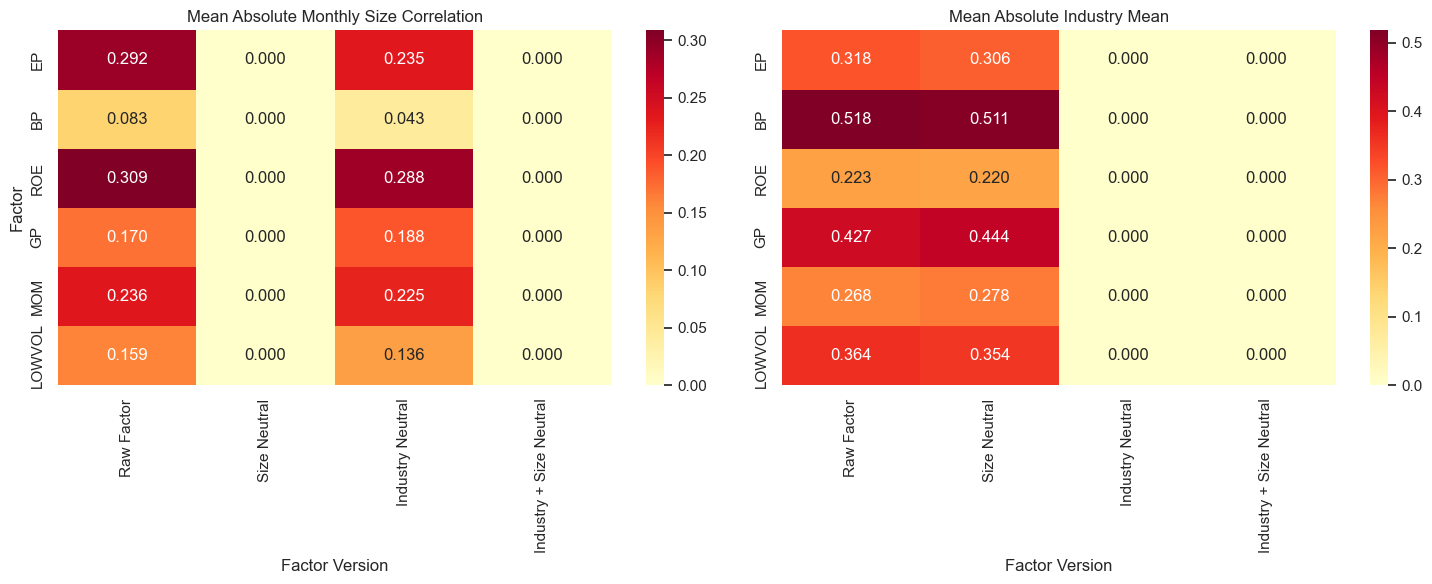

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    size_exposure.rename(index=FACTOR_LABELS),
    annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, ax=axes[0],
)
axes[0].set_title('Mean Absolute Monthly Size Correlation')
axes[0].set_xlabel('Factor Version')
axes[0].set_ylabel('Factor')
sns.heatmap(
    industry_exposure.rename(index=FACTOR_LABELS),
    annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, ax=axes[1],
)
axes[1].set_title('Mean Absolute Industry Mean')
axes[1].set_xlabel('Factor Version')
axes[1].set_ylabel('')
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_exposure_diagnostics.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

## 4. 中性化前后的因子结构

除了预测能力和组合收益，中性化还可能改变因子之间的信息重叠以及单个因子的跨期持续性。本节在不使用未来收益标签的当期合格股票池中进行两项比较：

1. **因子相关矩阵**：每个月计算不同因子之间的横截面 Spearman 相关，再对月份等权平均。若中性化后相关性明显下降，说明原始相关性的一部分来自共同的市值或行业暴露；相关性仍然较高则说明因子剩余信息本身仍有重叠。
2. **因子平均排名自相关**：对相邻两个调仓日共同存在的股票，计算同一因子排名的 Spearman 相关，再对月份平均。数值越高表示排序越持久，通常意味着潜在换手较低；但它只描述信号持续性，不代表预测能力更强。

为使四种规格可比，每个因子只使用四个版本均有值的股票—月份记录。因子相关性采用因子对之间的共同非缺失样本；排名自相关采用相邻月份中同一股票的共同非缺失样本。

In [5]:
eligible_mask = panels['Raw Factor']['is_eligible'].fillna(False).to_numpy()
common_signal_masks = {}
for factor in FACTOR_COLUMNS:
    common = eligible_mask.copy()
    for panel in panels.values():
        common &= panel[factor].notna().to_numpy()
    common_signal_masks[factor] = common

factor_correlations = {}
rank_autocorrelation_parts = []
for version in VERSIONS:
    structure_sample = panels[version].loc[
        :, ['date', 'stock_code', *FACTOR_COLUMNS]
    ].copy()
    for factor in FACTOR_COLUMNS:
        structure_sample.loc[~common_signal_masks[factor], factor] = np.nan

    factor_correlations[version] = calculate_average_factor_correlation(
        structure_sample,
        FACTOR_COLUMNS,
        method='spearman',
        min_observations=MIN_OBSERVATIONS,
    )
    rank_autocorrelation = calculate_factor_rank_autocorrelation(
        structure_sample,
        FACTOR_COLUMNS,
        min_observations=MIN_OBSERVATIONS,
    )
    rank_autocorrelation_parts.append(
        rank_autocorrelation.assign(Version=version)
    )
    del structure_sample

factor_correlation_export = pd.concat(
    factor_correlations, names=['Version', 'Factor']
)
factor_correlation_export.to_csv(
    PROCESSED_DIR / 'neutralization_factor_correlation_spearman.csv'
)
correlation_change = (
    factor_correlations['Industry + Size Neutral']
    - factor_correlations['Raw Factor']
)
correlation_change.to_csv(
    PROCESSED_DIR / 'neutralization_factor_correlation_change.csv'
)
display(
    correlation_change.rename(index=FACTOR_LABELS, columns=FACTOR_LABELS)
    .style.format('{:+.3f}').background_gradient(cmap='RdBu_r', axis=None)
)

,EP,BP,ROE,GP,MOM,LOWVOL
EP,+0.000,-0.056,-0.041,+0.015,-0.048,-0.089
BP,-0.056,+0.000,-0.011,+0.068,-0.004,-0.063
ROE,-0.041,-0.011,+0.000,+0.004,-0.040,-0.042
GP,+0.015,+0.068,+0.004,+0.000,-0.013,+0.029
MOM,-0.048,-0.004,-0.040,-0.013,+0.000,-0.030
LOWVOL,-0.089,-0.063,-0.042,+0.029,-0.030,+0.000


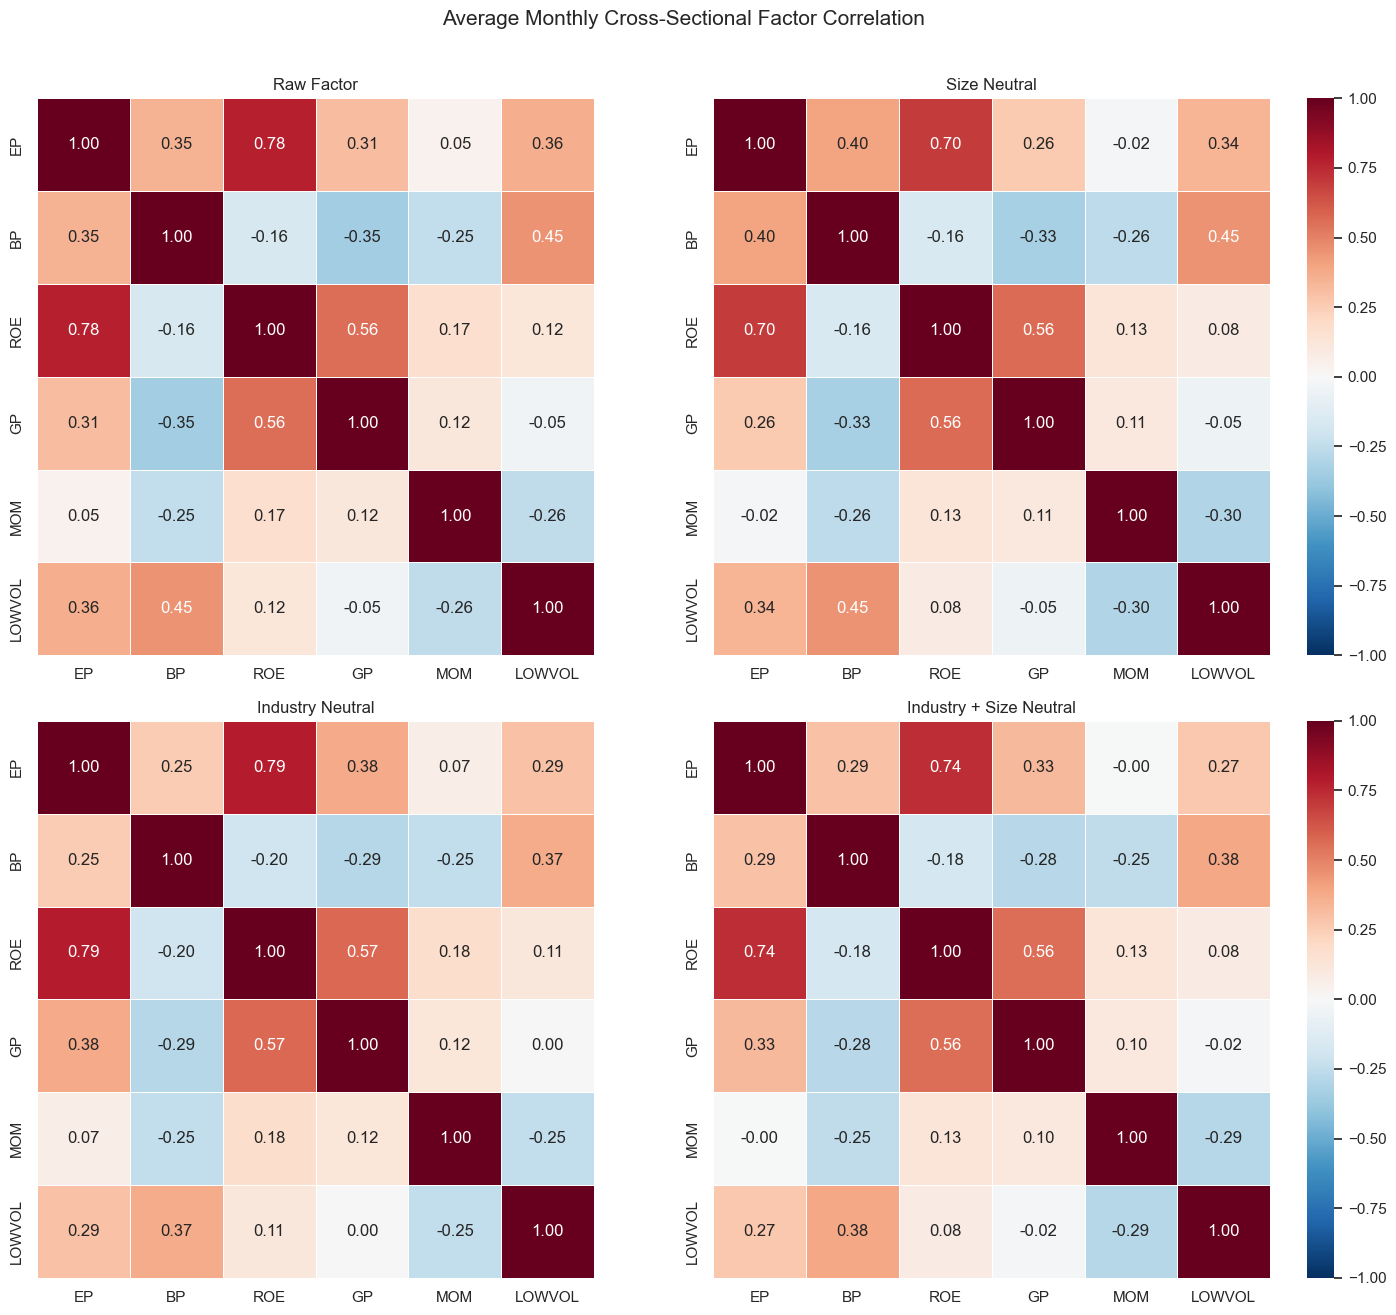

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
for ax, version in zip(axes.flat, VERSIONS):
    matrix = factor_correlations[version].rename(
        index=FACTOR_LABELS, columns=FACTOR_LABELS
    )
    sns.heatmap(
        matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, square=True, linewidths=0.5,
        cbar=ax in (axes[:, -1]), ax=ax,
    )
    ax.set_title(version)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle(
    'Average Monthly Cross-Sectional Factor Correlation',
    y=1.01, fontsize=15,
)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_factor_correlation_heatmaps.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

Version,Raw Factor,Size Neutral,Industry Neutral,Industry + Size Neutral
Factor Label,,,,
EP,0.973,0.967,0.968,0.962
BP,0.985,0.984,0.981,0.982
ROE,0.978,0.975,0.975,0.971
GP,0.992,0.991,0.989,0.989
MOM,0.866,0.864,0.869,0.864
LOWVOL,0.870,0.864,0.852,0.847


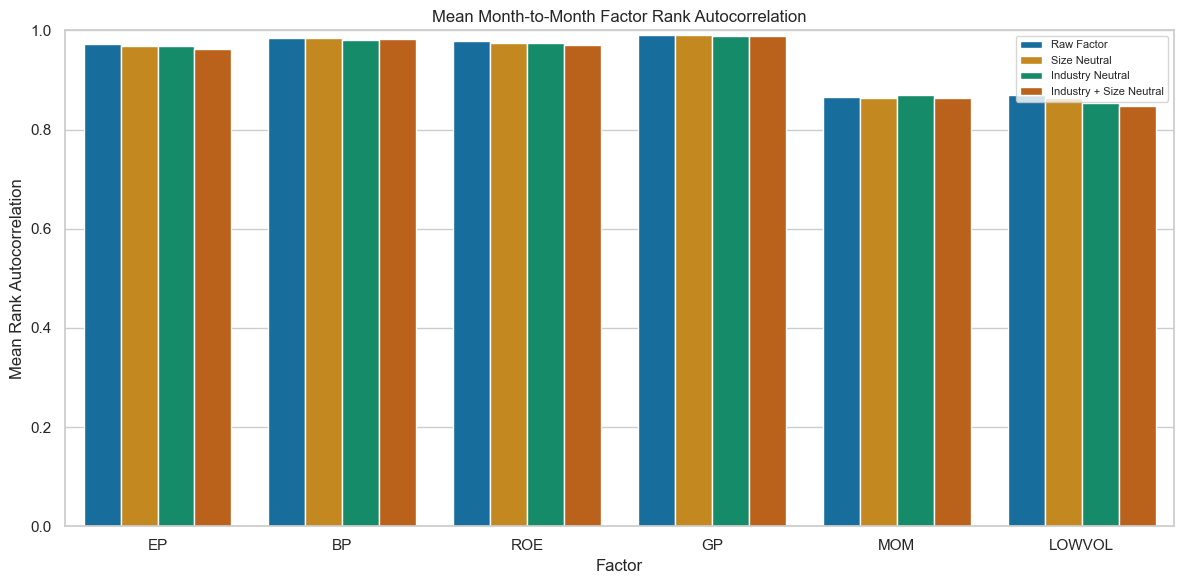

In [7]:
rank_autocorrelation_all = pd.concat(
    rank_autocorrelation_parts, ignore_index=True
)
rank_autocorrelation_all.to_parquet(
    PROCESSED_DIR / 'neutralization_factor_rank_autocorrelation.parquet',
    index=False,
)
rank_autocorrelation_summary = (
    rank_autocorrelation_all
    .groupby(['Version', 'factor'], observed=True)
    .agg(
        Mean_Rank_Autocorrelation=('rank_autocorrelation', 'mean'),
        Median_Rank_Autocorrelation=('rank_autocorrelation', 'median'),
        Valid_Month_Pairs=('rank_autocorrelation', 'count'),
        Median_Paired_Stocks=('n_stocks', 'median'),
    )
    .reset_index()
)
rank_autocorrelation_summary['Version'] = pd.Categorical(
    rank_autocorrelation_summary['Version'], VERSIONS, ordered=True
)
rank_autocorrelation_summary['Factor Label'] = (
    rank_autocorrelation_summary['factor'].map(FACTOR_LABELS)
)
rank_autocorrelation_summary['Factor Label'] = pd.Categorical(
    rank_autocorrelation_summary['Factor Label'],
    list(FACTOR_LABELS.values()), ordered=True,
)
rank_autocorrelation_summary = rank_autocorrelation_summary.sort_values(
    ['Factor Label', 'Version']
)
rank_autocorrelation_summary.to_csv(
    PROCESSED_DIR / 'neutralization_factor_rank_autocorrelation_summary.csv',
    index=False,
)
mean_rank_autocorrelation = rank_autocorrelation_summary.pivot(
    index='Factor Label', columns='Version',
    values='Mean_Rank_Autocorrelation',
)
display(
    mean_rank_autocorrelation.style.format('{:.3f}')
    .background_gradient(cmap='YlGn', axis=1)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=rank_autocorrelation_summary,
    x='Factor Label', y='Mean_Rank_Autocorrelation', hue='Version',
    hue_order=VERSIONS, palette=VERSION_COLORS, errorbar=None, ax=ax,
)
ax.set_title('Mean Month-to-Month Factor Rank Autocorrelation')
ax.set_xlabel('Factor')
ax.set_ylabel('Mean Rank Autocorrelation')
ax.set_ylim(0, 1)
ax.legend(title='', fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_rank_autocorrelation_comparison.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

## 5. 固定四版本共同样本

行业或市值字段缺失会使相应中性化版本缺失。若各版本直接使用各自最大样本，指标变化可能同时来自信号变化和样本变化。以下按因子保留四个版本都有值、且 `is_in_label_sample=True` 的共同记录。

In [8]:
label_mask = panels['Raw Factor']['is_in_label_sample'].fillna(False).to_numpy()
for factor in FACTOR_COLUMNS:
    common = label_mask.copy()
    for panel in panels.values():
        common &= panel[factor].notna().to_numpy()
    for panel in panels.values():
        panel.loc[~common, factor] = np.nan

coverage_rows = []
for factor in FACTOR_COLUMNS:
    monthly_counts = (
        panels['Raw Factor'].groupby('date', observed=True)[factor].count()
    )
    positive_counts = monthly_counts.loc[monthly_counts.gt(0)]
    coverage_rows.append({
        'Factor': FACTOR_LABELS[factor],
        'Months': len(positive_counts),
        'Minimum Stocks': positive_counts.min(),
        'Median Stocks': positive_counts.median(),
        'Maximum Stocks': positive_counts.max(),
    })
common_coverage = pd.DataFrame(coverage_rows).set_index('Factor')
display(common_coverage.astype(int))

,Months,Minimum Stocks,Median Stocks,Maximum Stocks
Factor,,,,
EP,95,2809,4106,4917
BP,95,2809,4106,4917
ROE,86,2881,3960,4877
GP,95,2733,3988,4787
MOM,95,2385,3816,4860
LOWVOL,95,2510,4050,4862


## 6. Rank IC 与 ICIR 比较

每个月计算因子与下一期收益的 Spearman Rank IC。ICIR 沿用 Notebook 04 的非年化定义：$Mean(IC)/Std(IC)$。中性化回归使用 Pearson OLS，而效果评估使用 Spearman IC：前者删除指定线性暴露，后者评价股票排序能力。

In [9]:
monthly_rank_ic = {}
ic_summary_parts = []
for version in VERSIONS:
    panel = panels[version]
    label_sample = panel.loc[
        panel['is_in_label_sample'].fillna(False),
        ['date', 'future_return_1m', *FACTOR_COLUMNS],
    ]
    monthly_rank_ic[version] = calculate_monthly_rank_ic(
        label_sample, FACTOR_COLUMNS, min_observations=MIN_OBSERVATIONS
    )
    summary = summarize_rank_ic(monthly_rank_ic[version]).reset_index()
    summary.insert(0, 'Version', version)
    ic_summary_parts.append(summary)

ic_summary = pd.concat(ic_summary_parts, ignore_index=True)
ic_summary['Factor Label'] = ic_summary['Factor'].map(FACTOR_LABELS)
ic_summary['Version'] = pd.Categorical(ic_summary['Version'], VERSIONS, ordered=True)
ic_summary['Factor Label'] = pd.Categorical(
    ic_summary['Factor Label'], list(FACTOR_LABELS.values()), ordered=True
)
ic_summary = ic_summary.sort_values(['Factor Label', 'Version'])
ic_summary.to_csv(PROCESSED_DIR / 'neutralization_ic_summary.csv', index=False)

monthly_ic_long = pd.concat(
    [table.assign(Version=version).rename_axis('date').reset_index()
     for version, table in monthly_rank_ic.items()],
    ignore_index=True,
)
monthly_ic_long.to_parquet(
    PROCESSED_DIR / 'neutralization_rank_ic_monthly.parquet', index=False
)

ic_comparison = ic_summary.pivot(
    index='Factor Label', columns='Version', values=['Mean Rank IC', 'ICIR']
)
display(ic_comparison.style.format('{:.4f}').background_gradient(cmap='RdYlGn', axis=1))

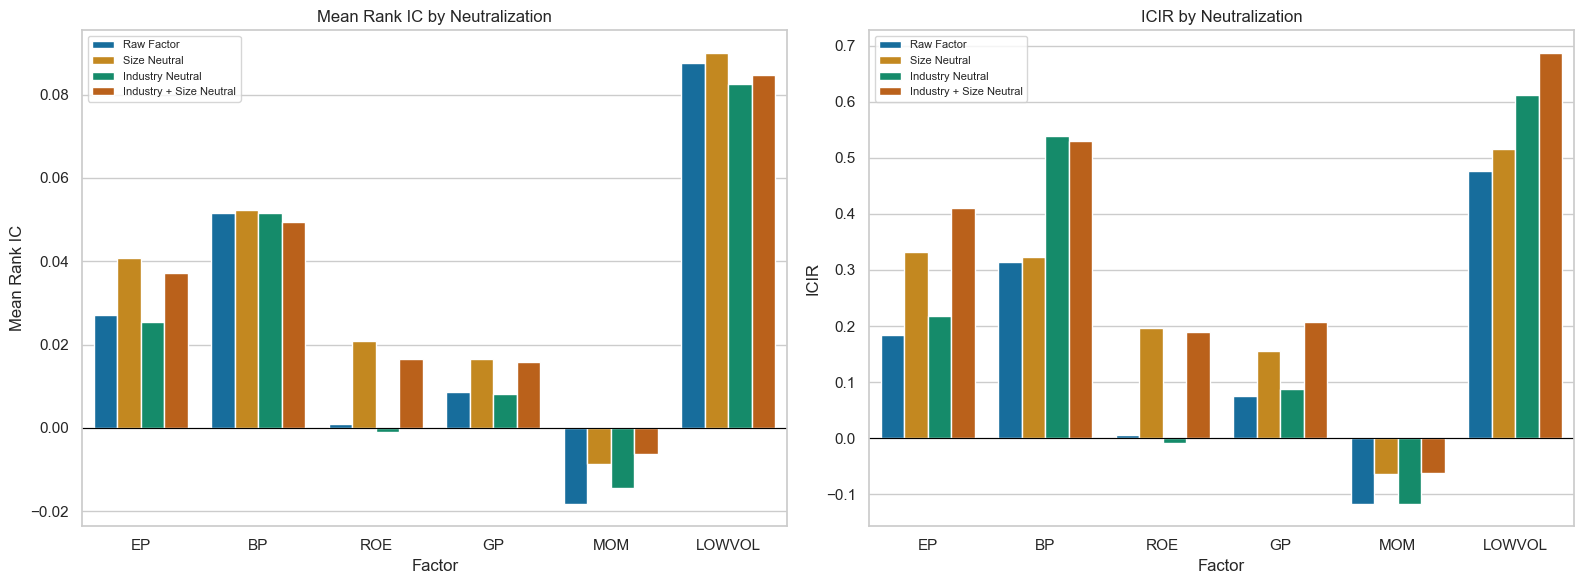

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, title in zip(
    axes,
    ['Mean Rank IC', 'ICIR'],
    ['Mean Rank IC by Neutralization', 'ICIR by Neutralization'],
):
    sns.barplot(
        data=ic_summary, x='Factor Label', y=metric, hue='Version',
        hue_order=VERSIONS, palette=VERSION_COLORS, ax=ax,
    )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Factor')
    ax.legend(title='', fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_ic_comparison.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

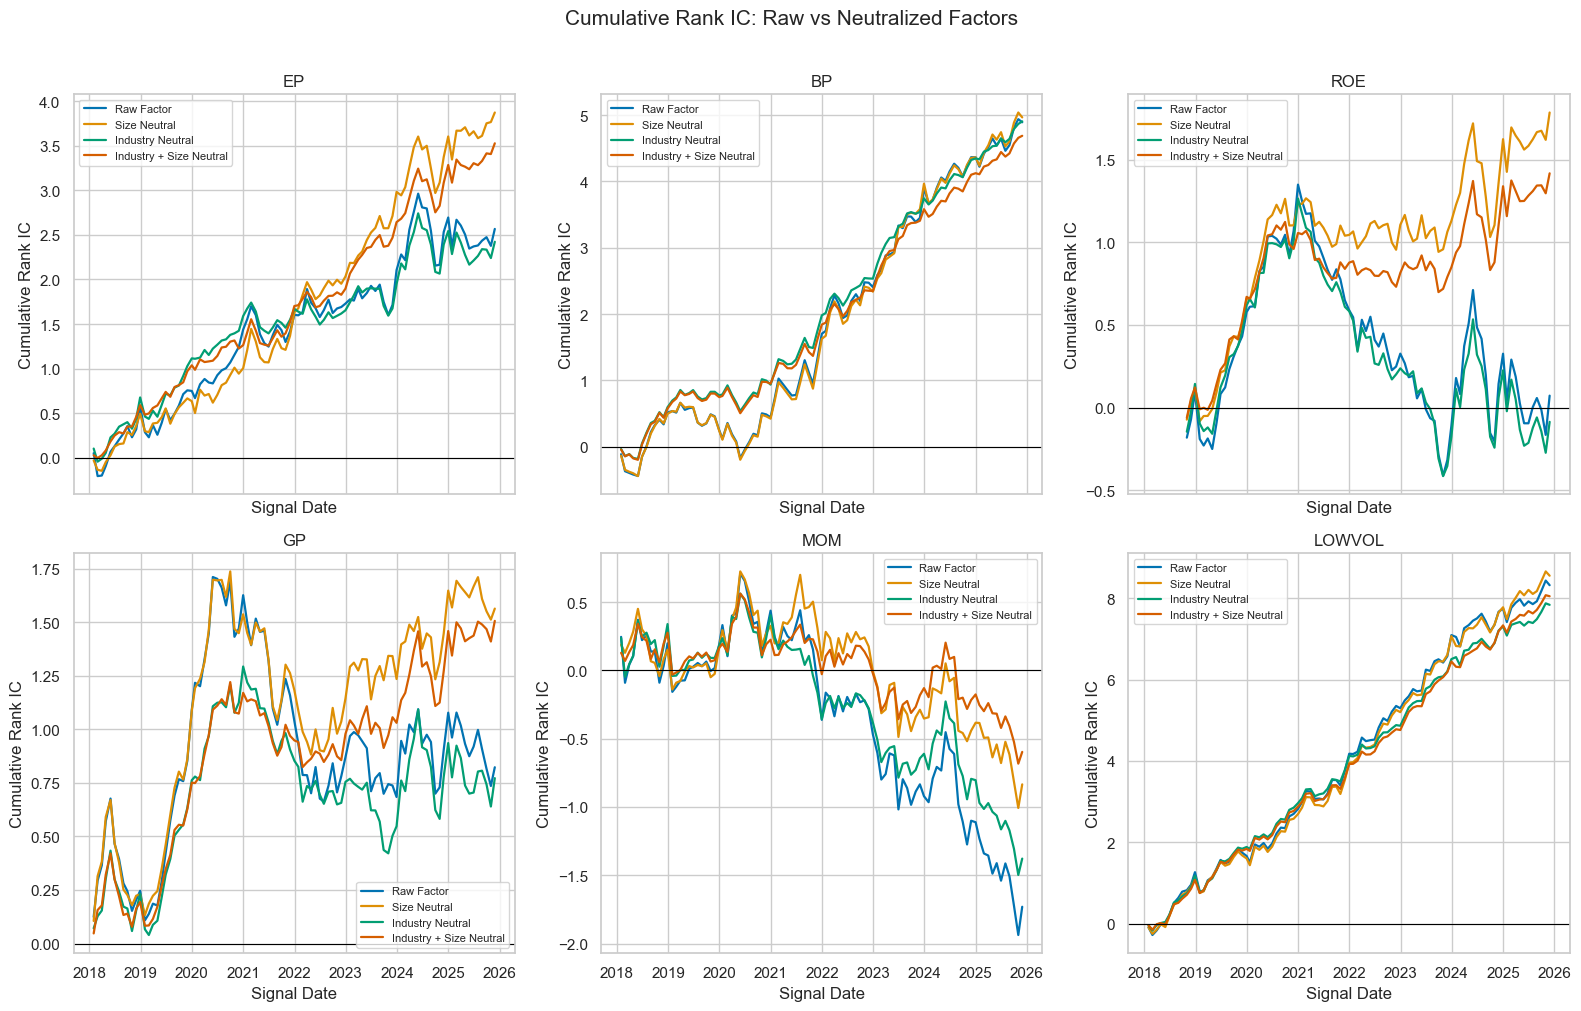

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True)
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    for version in VERSIONS:
        cumulative_ic = monthly_rank_ic[version][factor].cumsum()
        ax.plot(
            cumulative_ic.index, cumulative_ic, label=version,
            color=VERSION_COLORS[version], linewidth=1.6,
        )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(FACTOR_LABELS[factor])
    ax.set_xlabel('Signal Date')
    ax.set_ylabel('Cumulative Rank IC')
    ax.legend(fontsize=8)
fig.suptitle('Cumulative Rank IC: Raw vs Neutralized Factors', y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_cumulative_rank_ic.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

## 7. 五分位数与 Q5−Q1 比较

四个版本分别按月从低到高等频分成 Q1–Q5，组内等权，使用下一持有期简单收益。Q5−Q1 用于隔离高、低因子股票之间的相对收益，但在 A 股中仍是研究型组合；以下均为未扣交易成本的毛收益。

In [12]:
quintile_return_parts = []
quintile_summary_rows = []
performance_rows = []
long_short_returns = {}
quantile_names = [f'Q{number}' for number in range(1, N_QUANTILES + 1)]

for version in VERSIONS:
    panel = panels[version]
    backtest_sample = panel.loc[
        panel['is_in_label_sample'].fillna(False),
        ['date', 'stock_code', 'future_return_1m', *FACTOR_COLUMNS],
    ]
    quintile_returns = calculate_quintile_returns(
        backtest_sample,
        FACTOR_COLUMNS,
        n_quantiles=N_QUANTILES,
        min_observations=MIN_OBSERVATIONS,
    )
    quintile_return_parts.append(quintile_returns.assign(Version=version))

    for factor in FACTOR_COLUMNS:
        return_panel = build_factor_return_panel(
            quintile_returns, factor, n_quantiles=N_QUANTILES
        )
        long_short_returns[(version, factor)] = return_panel['Long-Short']
        annualized_quantiles = {
            quantile: annualized_return(
                return_panel[quantile], periods_per_year=PERIODS_PER_YEAR
            )
            for quantile in quantile_names
        }
        monotonicity = pd.Series(range(1, N_QUANTILES + 1), dtype=float).corr(
            pd.Series(list(annualized_quantiles.values()), dtype=float),
            method='spearman',
        )
        quintile_summary_rows.append({
            'Version': version, 'Factor': factor,
            **annualized_quantiles, 'Monotonicity': monotonicity,
        })
        metrics = calculate_return_metrics(
            return_panel['Long-Short'], periods_per_year=PERIODS_PER_YEAR
        )
        performance_rows.append({
            'Version': version, 'Factor': factor, **metrics.to_dict(),
        })

quintile_returns_all = pd.concat(quintile_return_parts, ignore_index=True)
quintile_summary = pd.DataFrame(quintile_summary_rows)
performance_summary = pd.DataFrame(performance_rows)
for table in (quintile_summary, performance_summary):
    table['Factor Label'] = table['Factor'].map(FACTOR_LABELS)
    table['Version'] = pd.Categorical(table['Version'], VERSIONS, ordered=True)

quintile_returns_all.to_parquet(
    PROCESSED_DIR / 'neutralization_quintile_returns.parquet', index=False
)
quintile_summary.to_csv(
    PROCESSED_DIR / 'neutralization_quintile_summary.csv', index=False
)
performance_summary.to_csv(
    PROCESSED_DIR / 'neutralization_long_short_summary.csv', index=False
)

performance_comparison = performance_summary.pivot(
    index='Factor Label', columns='Version',
    values=['Annualized Return', 'Sharpe Ratio'],
)
display(performance_comparison.style.format({
    ('Annualized Return', version): '{:.2%}' for version in VERSIONS
}).format({
    ('Sharpe Ratio', version): '{:.2f}' for version in VERSIONS
}).background_gradient(cmap='RdYlGn', axis=1))

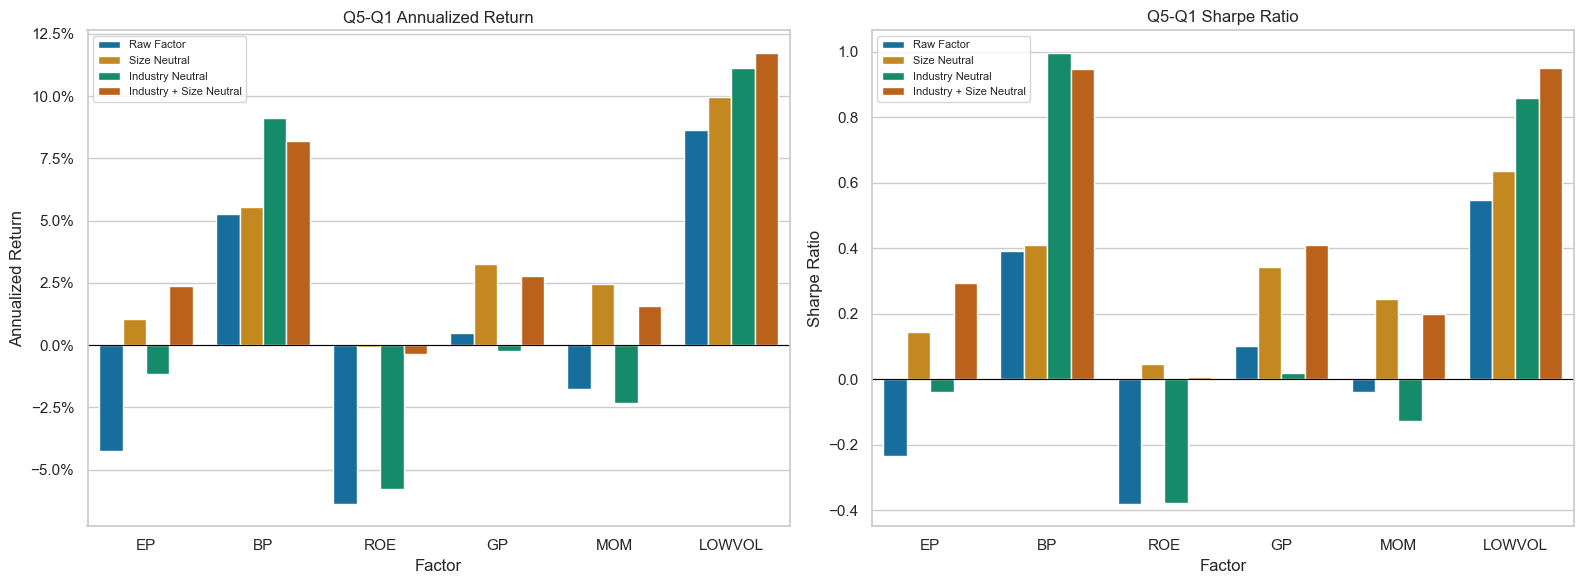

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, title in zip(
    axes,
    ['Annualized Return', 'Sharpe Ratio'],
    ['Q5-Q1 Annualized Return', 'Q5-Q1 Sharpe Ratio'],
):
    sns.barplot(
        data=performance_summary, x='Factor Label', y=metric, hue='Version',
        hue_order=VERSIONS, palette=VERSION_COLORS, ax=ax,
    )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Factor')
    ax.legend(title='', fontsize=8)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_long_short_comparison.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

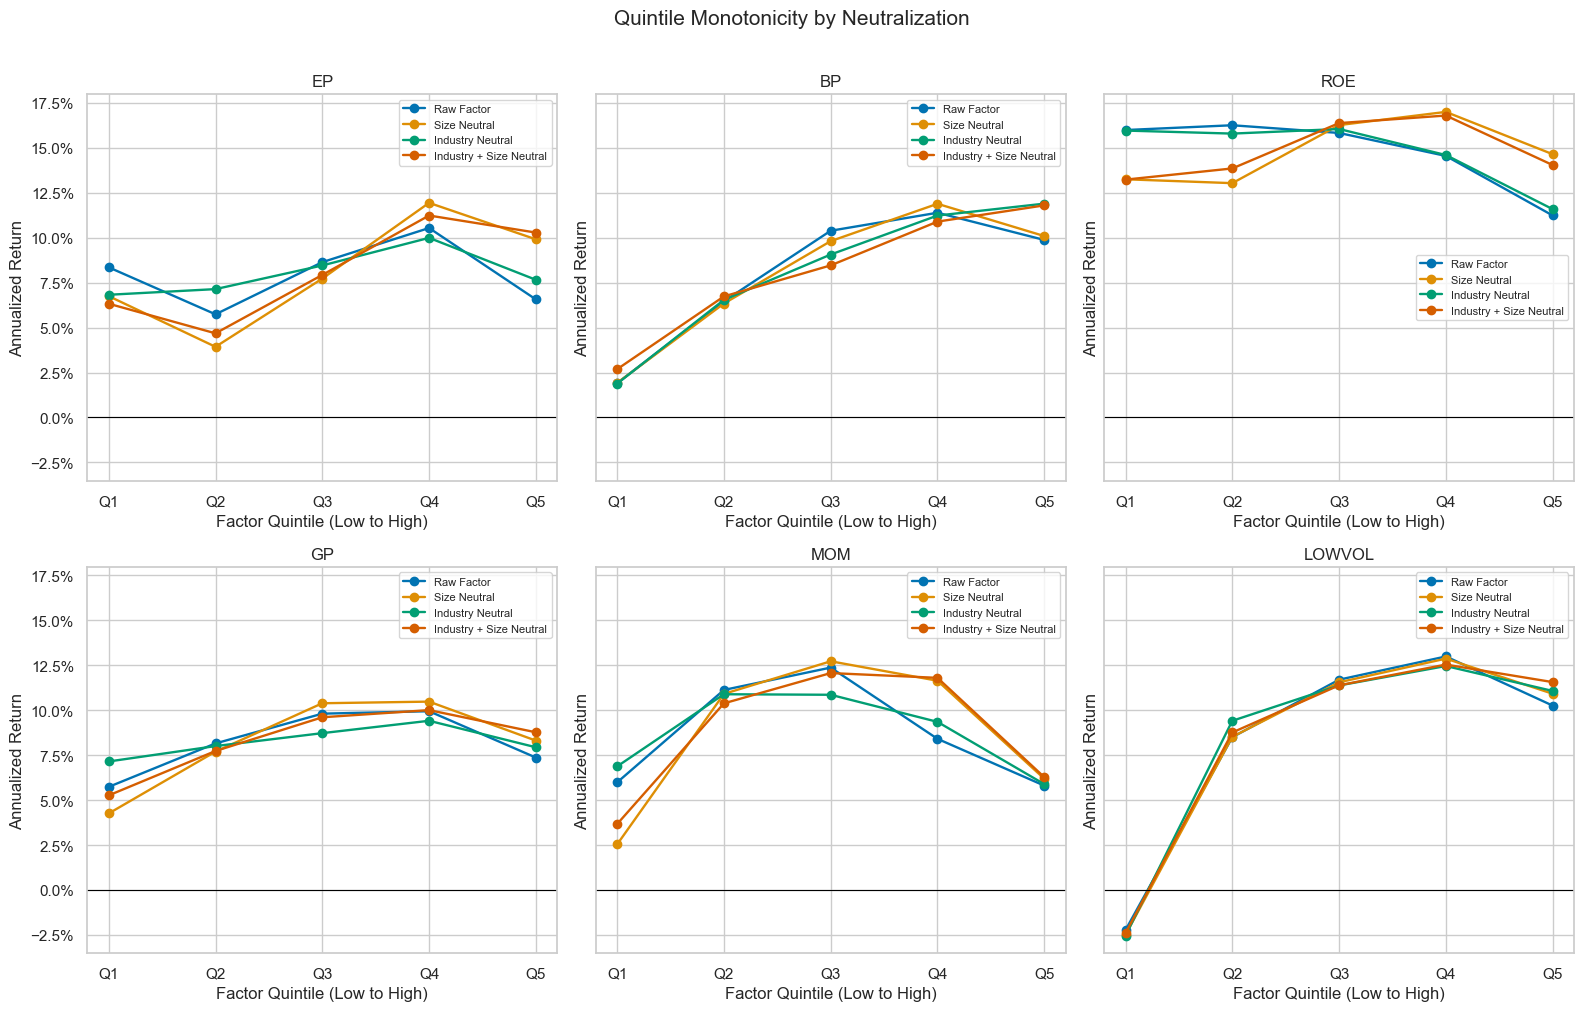

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    selected = quintile_summary.loc[quintile_summary['Factor'].eq(factor)]
    for version in VERSIONS:
        values = selected.loc[selected['Version'].eq(version), quantile_names].iloc[0]
        ax.plot(
            quantile_names, values, marker='o', label=version,
            color=VERSION_COLORS[version], linewidth=1.7,
        )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(FACTOR_LABELS[factor])
    ax.set_xlabel('Factor Quintile (Low to High)')
    ax.set_ylabel('Annualized Return')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(fontsize=8)
fig.suptitle('Quintile Monotonicity by Neutralization', y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_quintile_returns.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

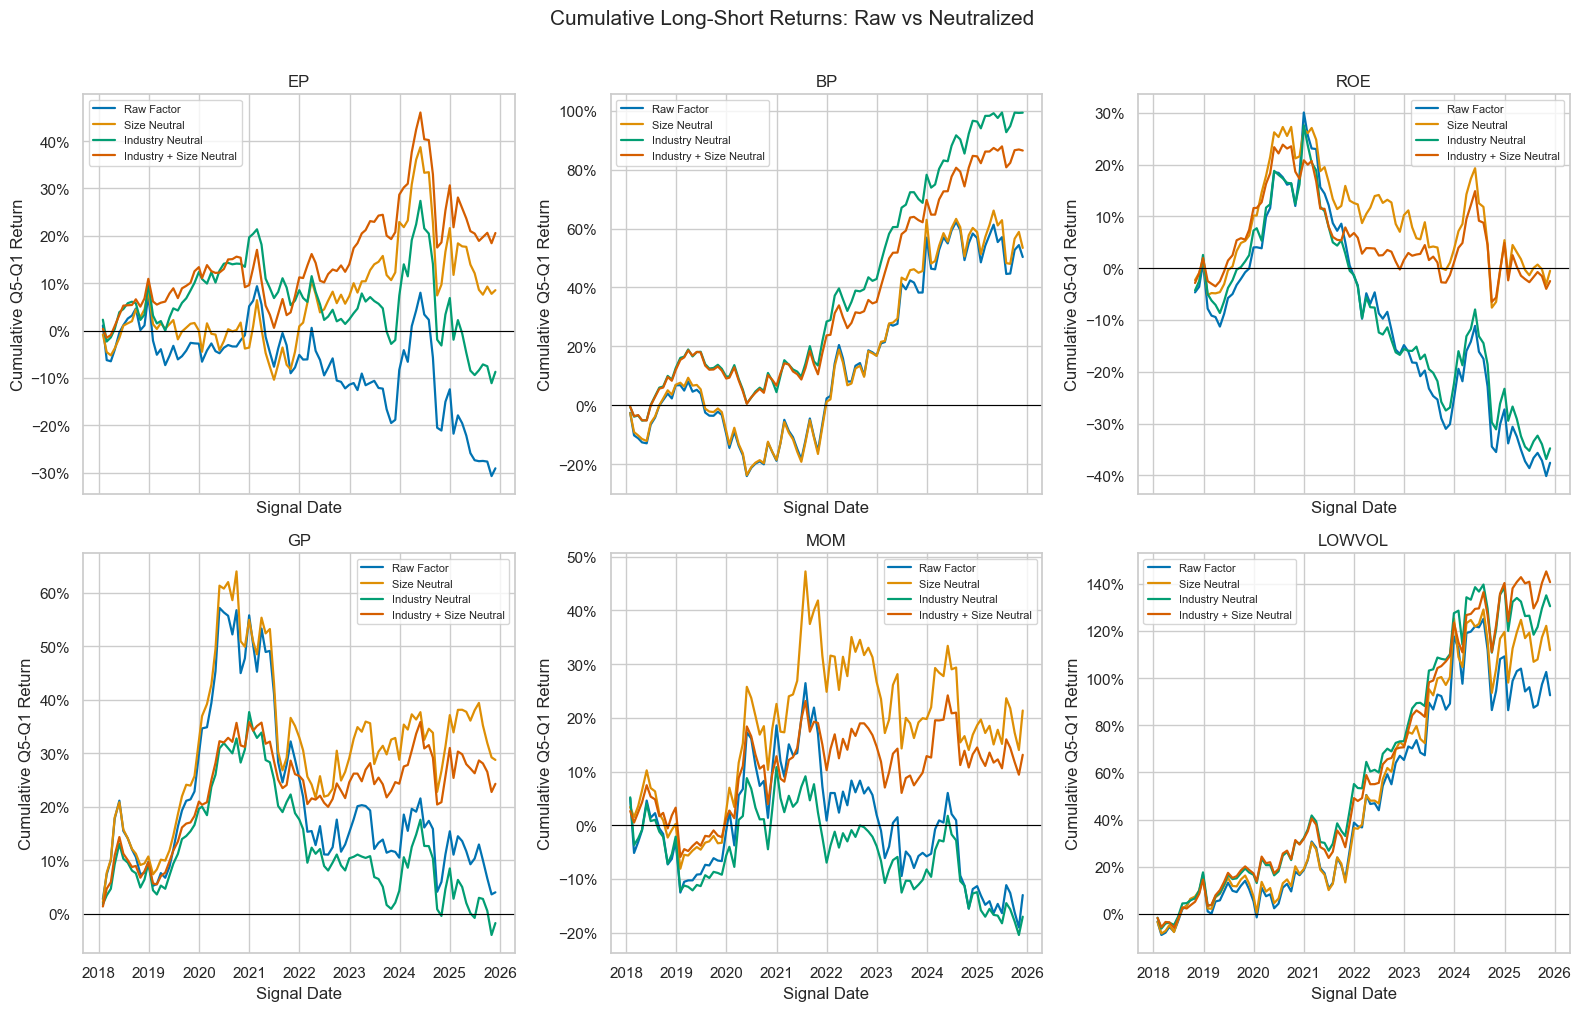

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True)
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    for version in VERSIONS:
        curve = calculate_cumulative_returns(long_short_returns[(version, factor)])
        ax.plot(
            curve.index, curve, label=version,
            color=VERSION_COLORS[version], linewidth=1.6,
        )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(FACTOR_LABELS[factor])
    ax.set_xlabel('Signal Date')
    ax.set_ylabel('Cumulative Q5-Q1 Return')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(fontsize=8)
fig.suptitle('Cumulative Long-Short Returns: Raw vs Neutralized', y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'neutralization_cumulative_long_short.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

## 8. Raw 与联合中性化的关键结果

下表集中比较基准版本和控制最完整的 `Industry + Size Neutral`。`IC Retention` 是联合中性化 Mean Rank IC 与原始 Mean Rank IC 的比值；当原始 IC 接近零时该比值不稳定，因此只把它作为描述性指标。

In [16]:
ic_wide = ic_summary.pivot(index='Factor', columns='Version', values='Mean Rank IC')
return_wide = performance_summary.pivot(
    index='Factor', columns='Version', values='Annualized Return'
)
sharpe_wide = performance_summary.pivot(
    index='Factor', columns='Version', values='Sharpe Ratio'
)

key_results = pd.DataFrame(index=FACTOR_COLUMNS)
key_results['Raw Mean IC'] = ic_wide['Raw Factor']
key_results['Joint-Neutral Mean IC'] = ic_wide['Industry + Size Neutral']
key_results['Mean IC Change'] = (
    key_results['Joint-Neutral Mean IC'] - key_results['Raw Mean IC']
)
key_results['IC Retention'] = (
    key_results['Joint-Neutral Mean IC'] / key_results['Raw Mean IC']
)
key_results['Raw LS Return'] = return_wide['Raw Factor']
key_results['Joint-Neutral LS Return'] = return_wide['Industry + Size Neutral']
key_results['Raw LS Sharpe'] = sharpe_wide['Raw Factor']
key_results['Joint-Neutral LS Sharpe'] = sharpe_wide['Industry + Size Neutral']
key_results = key_results.rename(index=FACTOR_LABELS)
key_results.to_csv(PROCESSED_DIR / 'neutralization_key_results.csv')

display(key_results.style.format({
    'Raw Mean IC': '{:.4f}',
    'Joint-Neutral Mean IC': '{:.4f}',
    'Mean IC Change': '{:+.4f}',
    'IC Retention': '{:.1%}',
    'Raw LS Return': '{:.2%}',
    'Joint-Neutral LS Return': '{:.2%}',
    'Raw LS Sharpe': '{:.2f}',
    'Joint-Neutral LS Sharpe': '{:.2f}',
}).background_gradient(
    subset=['Raw Mean IC', 'Joint-Neutral Mean IC'], cmap='RdYlGn'
))

best_joint_factor = key_results['Joint-Neutral Mean IC'].idxmax()
best_joint_sharpe = key_results['Joint-Neutral LS Sharpe'].idxmax()
print(
    f'联合中性化后 Mean Rank IC 最高：{best_joint_factor} '
    f"({key_results.loc[best_joint_factor, 'Joint-Neutral Mean IC']:.4f})"
)
print(
    f'联合中性化后 Q5−Q1 Sharpe 最高：{best_joint_sharpe} '
    f"({key_results.loc[best_joint_sharpe, 'Joint-Neutral LS Sharpe']:.2f})"
)

,Raw Mean IC,Joint-Neutral Mean IC,Mean IC Change,IC Retention,Raw LS Return,Joint-Neutral LS Return,Raw LS Sharpe,Joint-Neutral LS Sharpe
EP,0.0270,0.0371,+0.0101,137.4%,-4.25%,2.39%,-0.23,0.29
BP,0.0515,0.0493,-0.0021,95.8%,5.28%,8.19%,0.39,0.95
ROE,0.0008,0.0165,+0.0156,1955.4%,-6.37%,-0.35%,-0.38,0.01
GP,0.0087,0.0159,+0.0072,183.0%,0.49%,2.78%,0.10,0.41
MOM,-0.0182,-0.0063,+0.0119,34.5%,-1.74%,1.57%,-0.04,0.20
LOWVOL,0.0876,0.0847,-0.0029,96.7%,8.64%,11.73%,0.55,0.95


联合中性化后 Mean Rank IC 最高：LOWVOL (0.0847)
联合中性化后 Q5−Q1 Sharpe 最高：LOWVOL (0.95)


## 9. 解释原则与限制

- 中性化后 IC 或多空收益下降，说明原始结果的一部分可由市值或行业结构解释；下降不等于因子无效。
- 若联合中性化后方向、分组单调性和收益路径仍较稳定，才有证据认为因子包含更独立的个股信息。
- OLS 只删除指定变量的线性暴露，不能排除非线性市值效应、行业内风格暴露或遗漏风险变量。
- 本节使用共同样本保证版本可比，但结论仍是全样本诊断；参数选择和最终业绩评价仍应在严格的 Train / Validation / Test 框架下完成。
- Q5−Q1 尚未加入换手率、佣金、印花税、冲击成本和融券约束，不能直接视为可实现策略收益。